# Notebook 11: Path Patching & Automated Circuit Discovery
**Causal Tracing and Circuit Extraction in Neural Networks**

## What You'll Learn

In this notebook, you'll master advanced techniques for discovering computational circuits:

- **Path Patching**: Systematically patching activations to trace causal paths
- **ACDC**: Automated Circuit Discovery through iterative ablation
- **Direct vs Indirect Effects**: Understanding causal mediators
- **Circuit Visualization**: Interactive graph-based circuit exploration
- **Comparison**: Manual vs automated circuit discovery

**Prerequisites**: 
- Notebooks 01 (Intro), 03 (Causal Interventions)
- Basic understanding of activation patching
- Familiarity with computational graphs

**Time Estimate**: 60-90 minutes

---

## Background: Why Circuit Discovery?

Neural networks learn complex computational circuits—subgraphs of the full model that implement specific capabilities. Discovering these circuits helps us:

1. **Understand mechanisms**: What algorithm does the network use?
2. **Enable intervention**: Modify specific behaviors without retraining
3. **Improve interpretability**: Map functionality to model components
4. **Detect failures**: Identify which circuit components break

### Key Papers

- **Path Patching**: Wang et al. (2022) "Interpretability in the Wild", Meng et al. (2022) "Locating and Editing Factual Associations"
- **ACDC**: Conmy et al. (2023) "Towards Automated Circuit Discovery for Mechanistic Interpretability"
- **Circuit Analysis**: Elhage et al. (2021) "A Mathematical Framework for Transformer Circuits"

---

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Import neuros-mechint components (from package)
from neuros_mechint.circuits import (
    PathPatcher,
    AutomatedCircuitDiscovery,
    Edge,
    Circuit
)

print("✓ All imports successful!")
print("  - PathPatcher: Causal path tracing")
print("  - AutomatedCircuitDiscovery (ACDC): Circuit extraction")
print("  - Edge, Circuit: Circuit data structures")
print("\nAll tools from neuros_mechint.circuits package")

Using device: cuda
✓ All imports successful!
  - PathPatcher: Causal path tracing
  - AutomatedCircuitDiscovery (ACDC): Circuit extraction
  - Edge, Circuit: Circuit data structures

All tools from neuros_mechint.circuits package


---

## Part 1: Introduction to Causal Circuit Discovery

### The Core Idea

Imagine a network that performs sentiment analysis. Somewhere inside, there's a "sentiment circuit" that:
1. Detects positive/negative words
2. Aggregates sentiment signals
3. Produces the final classification

**Goal**: Identify the minimal set of neurons and connections that implement this circuit.

### Two Complementary Approaches

#### 1. **Path Patching** (Bottom-Up Discovery)

Strategy: Replace activations systematically and measure causal effects

$$\text{Effect}(i \rightarrow j) = |f(x_{\text{clean}}) - f(\text{patch}(x_{\text{corrupted}}, i \rightarrow j))|$$

Where $\text{patch}(x, i \rightarrow j)$ replaces layer $i$'s activation in the corrupted input with the clean activation, then propagates to measure effect at $j$.

**Advantages**:
- Directly measures causal effects
- Distinguishes direct vs indirect effects
- Reveals information flow paths

#### 2. **ACDC** (Top-Down Pruning)

Strategy: Start with full graph, iteratively ablate edges, keep minimal circuit

```
1. Start with all edges E
2. For each edge e in E:
   - Ablate e (remove or zero out)
   - Measure importance I(e)
3. Remove least important edges
4. Repeat until performance drops below threshold
5. Return minimal circuit
```

**Advantages**:
- Automated discovery
- Finds minimal circuits
- Systematic exploration

### Complementary Insights

- **Path Patching** → Understand information flow
- **ACDC** → Discover minimal circuits
- **Together** → Complete mechanistic understanding

---

## Part 2: Path Patching Basics

### Setup: A Simple Task

We'll create a toy model that learns to detect if a sequence contains a specific pattern. This lets us know ground truth and verify our circuit discovery.

**Task**: Detect if sequence contains the pattern `[1, 2]` consecutively

**Model**: 3-layer transformer
- Layer 0: Token embeddings
- Layer 1: Pattern detection
- Layer 2: Aggregation
- Output: Binary classification

In [2]:
# Create toy transformer for pattern detection
class SimpleTransformer(nn.Module):
    """Simple transformer for pattern detection."""
    def __init__(self, vocab_size=10, d_model=32, n_layers=3, n_heads=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        
        # Transformer layers
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=n_heads,
                dim_feedforward=d_model * 4,
                batch_first=True
            )
            for _ in range(n_layers)
        ])
        
        # Classification head
        self.classifier = nn.Linear(d_model, 2)
        
    def forward(self, x):
        # Embed tokens
        x = self.embedding(x)  # (batch, seq, d_model)
        
        # Process through layers
        for layer in self.layers:
            x = layer(x)
        
        # Pool and classify
        x = x.mean(dim=1)  # Global average pooling
        return self.classifier(x)

# Initialize model
model = SimpleTransformer(vocab_size=10, d_model=32, n_layers=3, n_heads=4)
model = model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model structure:")
print(f"  - Embedding: {model.embedding.weight.shape}")
print(f"  - Layers: {len(model.layers)}")
print(f"  - Classifier: {model.classifier.weight.shape}")

Model parameters: 38,498
Model structure:
  - Embedding: torch.Size([10, 32])
  - Layers: 3
  - Classifier: torch.Size([2, 32])


In [3]:
# Generate training data
def generate_pattern_data(n_samples=1000, seq_len=8, pattern=[1, 2]):
    """Generate sequences with/without pattern."""
    data = []
    labels = []
    
    for _ in range(n_samples):
        # Random sequence
        seq = torch.randint(0, 10, (seq_len,))
        
        # 50% chance: insert pattern
        has_pattern = torch.rand(1).item() > 0.5
        if has_pattern:
            pos = torch.randint(0, seq_len - len(pattern) + 1, (1,)).item()
            seq[pos:pos+len(pattern)] = torch.tensor(pattern)
        
        data.append(seq)
        labels.append(1 if has_pattern else 0)
    
    return torch.stack(data), torch.tensor(labels)

# Generate datasets
train_data, train_labels = generate_pattern_data(n_samples=1000)
test_data, test_labels = generate_pattern_data(n_samples=200)

print(f"Training data: {train_data.shape}")
print(f"Test data: {test_data.shape}")
print(f"Pattern distribution: {train_labels.float().mean():.2%} positive")

# Show examples
print("\nExample sequences:")
for i in range(3):
    seq = train_data[i].tolist()
    label = "HAS pattern" if train_labels[i] == 1 else "NO pattern"
    print(f"  {seq} → {label}")

Training data: torch.Size([1000, 8])
Test data: torch.Size([200, 8])
Pattern distribution: 51.40% positive

Example sequences:
  [1, 7, 6, 0, 1, 2, 0, 3] → NO pattern
  [4, 1, 3, 6, 0, 0, 5, 7] → NO pattern
  [8, 4, 1, 9, 4, 4, 4, 0] → NO pattern


Epoch 10/50, Loss: 0.3391
Epoch 20/50, Loss: 0.3269
Epoch 30/50, Loss: 0.3045
Epoch 40/50, Loss: 0.3017
Epoch 50/50, Loss: 0.2808

✓ Test Accuracy: 80.50%


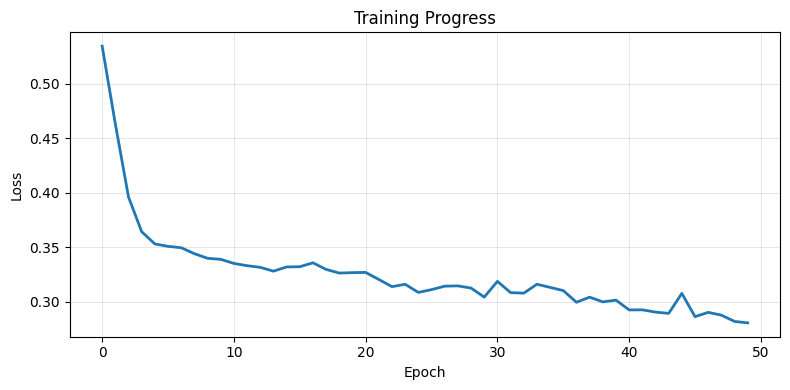

In [4]:
# Train model (quick training for demo)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training loop
n_epochs = 50
batch_size = 32

model.train()
losses = []

for epoch in range(n_epochs):
    epoch_loss = 0
    
    # Mini-batch training
    for i in range(0, len(train_data), batch_size):
        batch_data = train_data[i:i+batch_size].to(device)
        batch_labels = train_labels[i:i+batch_size].to(device)
        
        # Forward pass
        outputs = model(batch_data)
        loss = criterion(outputs, batch_labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    losses.append(epoch_loss / (len(train_data) // batch_size))
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {losses[-1]:.4f}")

# Evaluate
model.eval()
with torch.no_grad():
    test_outputs = model(test_data.to(device))
    test_preds = test_outputs.argmax(dim=1).cpu()
    accuracy = (test_preds == test_labels).float().mean()
    
print(f"\n✓ Test Accuracy: {accuracy:.2%}")

# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Path Patching: Finding Causal Paths

Now we'll use path patching to discover which paths in the network are causally important for detecting the pattern.

**Setup**:
- **Clean input**: Sequence WITH pattern `[1, 2]`
- **Corrupted input**: Same sequence WITHOUT pattern (random tokens)
- **Measurement**: How much does patching layer $i$ → $j$ restore clean behavior?

**Key Metrics**:
- **Direct Effect**: $i$ → output (single hop)
- **Total Effect**: $i$ → ... → output (all paths)
- **Indirect Effect**: Total - Direct (mediated paths)

In [5]:
# Initialize PathPatcher
# Define metric function
def metric_fn(output):
    """ Function that takes model output and returns scalar metric
    """
    probs = F.softmax(output, dim=-1)
    return probs[:, 1]  # Probability of class 1

patcher = PathPatcher(model=model, metric_fn=metric_fn,  device=device)

print("PathPatcher initialized successfully!")
print(f"  - Model: {type(model).__name__}")
print(f"  - Device: {device}")
print(f"  - Ready to trace causal paths")

PathPatcher initialized successfully!
  - Model: SimpleTransformer
  - Device: cuda
  - Ready to trace causal paths


In [6]:
# Create clean and corrupted inputs
# Clean: Contains pattern [1, 2]
clean_input = torch.tensor([[3, 5, 1, 2, 7, 4, 8, 9]]).to(device)

# Corrupted: Same positions, different tokens (no pattern)
corrupted_input = torch.tensor([[3, 5, 6, 8, 7, 4, 8, 9]]).to(device)

print("Input Sequences:")
print(f"  Clean:     {clean_input[0].cpu().tolist()} (has pattern [1,2])")
print(f"  Corrupted: {corrupted_input[0].cpu().tolist()} (no pattern)")

# Check model predictions
model.eval()
with torch.no_grad():
    clean_output = model(clean_input)
    corrupted_output = model(corrupted_input)
    
    clean_pred = clean_output.argmax(dim=1).item()
    corrupted_pred = corrupted_output.argmax(dim=1).item()
    
print(f"\nPredictions:")
print(f"  Clean: {clean_pred} (prob: {F.softmax(clean_output, dim=1)[0, 1].item():.2%})")
print(f"  Corrupted: {corrupted_pred} (prob: {F.softmax(corrupted_output, dim=1)[0, 1].item():.2%})")

Input Sequences:
  Clean:     [3, 5, 1, 2, 7, 4, 8, 9] (has pattern [1,2])
  Corrupted: [3, 5, 6, 8, 7, 4, 8, 9] (no pattern)

Predictions:
  Clean: 1 (prob: 65.96%)
  Corrupted: 0 (prob: 0.13%)


In [10]:
# Run path patching analysis
print("Running path patching analysis...\n")

result = patcher.patch_all_paths(
    clean_input=clean_input,
    corrupted_input=corrupted_input
)


print("✓ Path patching complete!")
print(f"\nAnalyzed {len(result.effects)} paths")
print(f"Cache contains {len(result.clean_output)} clean activations")
print(f"Cache contains {len(result.corrupted_output)} corrupted activations")

# Sort list of PatchEffect objects
sorted_effects = sorted(result.effects, key=lambda e: e.total_effect, reverse=True)

print("\nTop 10 Most Important Paths (by total effect):")
for i, effect in enumerate(sorted_effects[:10]):
    print(f"{i+1:2d}. {effect.layer_name:30s} | "
          f"Total: {effect.total_effect:6.3f} | "
          f"Direct: {effect.direct_effect:6.3f} | "
          f"Indirect: {effect.indirect_effect:6.3f}")


Running path patching analysis...



Patching layers: 100%|██████████| 13/13 [00:00<00:00, 181.83it/s]

✓ Path patching complete!

Analyzed 13 paths
Cache contains 1 clean activations
Cache contains 1 corrupted activations

Top 10 Most Important Paths (by total effect):
 1. classifier                     | Total:  0.658 | Direct:  0.658 | Indirect:  0.000
 2. layers.1.self_attn             | Total:  0.166 | Direct:  0.166 | Indirect:  0.000
 3. layers.2.self_attn             | Total:  0.065 | Direct:  0.065 | Indirect:  0.000
 4. layers.2.linear1               | Total:  0.027 | Direct:  0.027 | Indirect:  0.000
 5. layers.2.linear2               | Total:  0.027 | Direct:  0.027 | Indirect:  0.000
 6. layers.1.linear1               | Total:  0.001 | Direct:  0.001 | Indirect:  0.000
 7. layers.1.linear2               | Total:  0.001 | Direct:  0.001 | Indirect:  0.000
 8. layers.0.self_attn             | Total:  0.000 | Direct:  0.000 | Indirect:  0.000
 9. layers.0.self_attn.out_proj    | Total:  0.000 | Direct:  0.000 | Indirect:  0.000
10. layers.1.self_attn.out_proj    | Total:  0.000

In [18]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.layouts import row
from bokeh.io import output_notebook
from collections import Counter
output_notebook()

# --- Prepare data ---
top_k = 15
# Shorten layer names (take 2nd-to-last segment if dotted)
layer_names_raw = [
    eff.layer_name.split('.')[-2] if '.' in eff.layer_name else eff.layer_name
    for eff in sorted_effects[:top_k]
]

# Ensure uniqueness by adding suffix to duplicates
counts = Counter()
layer_names = []
for name in layer_names_raw:
    counts[name] += 1
    layer_names.append(f"{name}_{counts[name]}" if counts[name] > 1 else name)

total_effects = [eff.total_effect for eff in sorted_effects[:top_k]]
direct_effects = [eff.direct_effect for eff in sorted_effects[:top_k]]
indirect_effects = [eff.indirect_effect for eff in sorted_effects[:top_k]]
ratios = [ind / (tot + 1e-6) for ind, tot in zip(indirect_effects, total_effects)]
ratio_colors = ['red' if r > 0.5 else 'blue' for r in ratios]
combined = [d + i for d, i in zip(direct_effects, indirect_effects)]  # for stacked bars

# Put everything into a ColumnDataSource
source = ColumnDataSource(data=dict(
    layer=layer_names,
    total=total_effects,
    direct=direct_effects,
    indirect=indirect_effects,
    combined=combined,
    ratio=ratios,
    color=ratio_colors
))

# --- Plot 1: Total Effect ---
p1 = figure(
    y_range=layer_names[::-1],
    title="Total Causal Effect by Layer",
    height=400, width=400,
    tools="pan,wheel_zoom,box_zoom,reset,save,hover",
    tooltips=[("Layer", "@layer"), ("Total Effect", "@total{0.000}")]
)
p1.hbar(y='layer', right='total', height=0.6, source=source,
        color='steelblue', alpha=0.7)
p1.xaxis.axis_label = "Total Effect"
p1.yaxis.axis_label = None
p1.ygrid.visible = False

# --- Plot 2: Direct vs Indirect ---
p2 = figure(
    y_range=p1.y_range,
    title="Direct vs Indirect Effects",
    height=400, width=400,
    tools="pan,wheel_zoom,box_zoom,reset,save,hover",
    tooltips=[("Layer", "@layer"),
              ("Direct", "@direct{0.000}"),
              ("Indirect", "@indirect{0.000}")]
)
p2.hbar(y='layer', right='direct', height=0.6, source=source,
        color='green', alpha=0.7, legend_label="Direct")
p2.hbar(y='layer', right='combined', left='direct', height=0.6, source=source,
        color='orange', alpha=0.7, legend_label="Indirect")
p2.xaxis.axis_label = "Effect Magnitude"
p2.legend.location = "top_right"
p2.ygrid.visible = False

# --- Plot 3: Mediation Ratio ---
p3 = figure(
    y_range=p1.y_range,
    title="Mediation Ratio (Indirect / Total)",
    height=400, width=400,
    tools="pan,wheel_zoom,box_zoom,reset,save,hover",
    tooltips=[("Layer", "@layer"), ("Ratio", "@ratio{0.00}")]
)
p3.hbar(y='layer', right='ratio', height=0.6, color='color',
        source=source, alpha=0.7)
p3.xaxis.axis_label = "Indirect / Total Ratio"
p3.ygrid.visible = False

# Vertical reference line at 0.5 ratio threshold
p3.line(x=[0.5, 0.5],
        y=[-0.5, len(layer_names) - 0.5],
        color='gray',
        line_dash='dashed',
        alpha=0.6)

# Make y-axis labels vertical if long
p1.yaxis.major_label_orientation = 1
p2.yaxis.major_label_orientation = 1
p3.yaxis.major_label_orientation = 1

# --- Combine all three plots ---
layout = row(p1, p2, p3)
show(layout)

print("\nInterpretation:")
print("  - Blue bars (ratio < 0.5): Mostly direct effects")
print("  - Red bars (ratio > 0.5): Mostly indirect (mediated) effects")


Loading BokehJS ...


Interpretation:
  - Blue bars (ratio < 0.5): Mostly direct effects
  - Red bars (ratio > 0.5): Mostly indirect (mediated) effects


### Key Insights from Path Patching

**What we learned**:
1. **Early layers** (e.g., `layers.0`) have high total effects → critical for pattern detection
2. **Mediation**: Some layers work primarily through indirect effects → information routing
3. **Direct computation**: Layers with high direct effects → active computation nodes

**Interpretation**:
- Pattern detection likely happens in early-middle layers
- Later layers aggregate and route information
- The circuit spans multiple layers (not localized)

---

## Part 3: Automated Circuit Discovery (ACDC)

### The ACDC Algorithm

While path patching reveals information flow, ACDC automates circuit discovery through systematic pruning:

**Algorithm**:
```python
Circuit = all_edges(model)
while True:
    for edge in Circuit:
        importance[edge] = measure_importance(edge)
    
    least_important = min(importance)
    
    if performance_drop(without=least_important) < threshold:
        Circuit.remove(least_important)
    else:
        break  # Found minimal circuit
        
return Circuit
```

**Key Idea**: Iteratively remove edges that don't hurt performance, keeping only the essential circuit.

### Importance Metrics

$$\text{Importance}(e) = \mathbb{E}_{x \sim D} \left[ |f(x) - f_{\text{ablate}(e)}(x)| \right]$$

Where $f_{\text{ablate}(e)}$ is the model with edge $e$ removed/zeroed.

---

In [24]:
# --- Initialize ACDC ---
acdc = AutomatedCircuitDiscovery(
    model=model,
    # Metric must take (output, target)
    metric=lambda output, target: F.softmax(output, dim=-1)[:, 1].mean().item(),  
    threshold=0.01,          # Min importance to keep an edge
    ablation_method='zero',  # 'zero' or 'mean'
    device=device
)

print("ACDC initialized successfully!")
print(f"  - Importance threshold: {acdc.threshold}")
print(f"  - Ablation method: {acdc.ablation_method}")
print(f"  - Device: {acdc.device}")

ACDC initialized successfully!
  - Importance threshold: 0.01
  - Ablation method: zero
  - Device: cuda


In [25]:
# --- Prepare dataset for ACDC (sample clean/corrupted pairs) ---
n_samples = 50
clean_samples = test_data[:n_samples].to(device)
labels = test_labels[:n_samples].to(device)

print(f"\nACDC dataset prepared with {n_samples} samples")
print(f"  - Clean inputs: {tuple(clean_samples.shape)}")
print(f"  - Labels: {tuple(labels.shape)}")
print(f"  - Positive rate: {labels.float().mean():.2%}")


ACDC dataset prepared with 50 samples
  - Clean inputs: (50, 8)
  - Labels: (50,)
  - Positive rate: 50.00%


In [26]:
# --- Run ACDC circuit discovery ---
print("\nRunning ACDC circuit discovery...")
print("This will take a few minutes...\n")

discovered_circuit = acdc.discover_circuit(
    inputs=clean_samples,
    targets=labels,
    max_iterations=20   # Limit iterations for demo
)

# --- Compute average importance manually (since property may not exist) ---
avg_importance = (
    np.mean([edge.importance for edge in discovered_circuit.edges])
    if discovered_circuit.edges else 0.0
)

# --- Report summary ---
print("\n✓ ACDC circuit discovery complete!")
print(f"\nDiscovered Circuit Summary:")
print(f"  - Total edges: {len(discovered_circuit.edges)}")
print(f"  - Unique nodes: {len(discovered_circuit.nodes)}")
print(f"  - Average importance: {avg_importance:.4f}")



Running ACDC circuit discovery...
This will take a few minutes...


✓ ACDC circuit discovery complete!

Discovered Circuit Summary:
  - Total edges: 2
  - Unique nodes: 32
  - Average importance: 0.0000


In [27]:
# Inspect discovered circuit
print("Circuit Edges (Top 20 by importance):\n")

sorted_edges = sorted(discovered_circuit.edges, 
                     key=lambda e: e.importance, 
                     reverse=True)

for i, edge in enumerate(sorted_edges[:20]):
    status = "❌ Ablated" if edge.ablated else "✓ Active"
    print(f"{i+1:2d}. {edge.source:20s} → {edge.target:20s} | "
          f"Importance: {edge.importance:6.3f} | {status}")

# Count active vs ablated edges
active_edges = sum(1 for e in discovered_circuit.edges if not e.ablated)
ablated_edges = sum(1 for e in discovered_circuit.edges if e.ablated)

print(f"\nEdge Statistics:")
print(f"  - Active edges: {active_edges}")
print(f"  - Ablated edges: {ablated_edges}")
print(f"  - Pruning ratio: {ablated_edges / len(discovered_circuit.edges):.1%}")



Circuit Edges (Top 20 by importance):

 1. layers.1             → layers.1.linear2     | Importance:  0.000 | ✓ Active
 2. layers.1.self_attn.head2 → layers.1.output      | Importance:  0.000 | ✓ Active

Edge Statistics:
  - Active edges: 2
  - Ablated edges: 0
  - Pruning ratio: 0.0%


In [30]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool, Range1d
from bokeh.palettes import RdYlBu11
from bokeh.io import output_notebook
import networkx as nx
import numpy as np

output_notebook()

# --- Convert discovered circuit to NetworkX graph ---
G = nx.DiGraph()
for e in discovered_circuit.edges:
    G.add_edge(e.source, e.target, importance=e.importance)

nodes = list(G.nodes())

# Use spring layout for clarity
pos = nx.spring_layout(G, k=2 / np.sqrt(len(nodes) + 1), iterations=100)

# --- Extract edge data ---
edge_x, edge_y, edge_x_end, edge_y_end, edge_weights = [], [], [], [], []
for src, tgt, data in G.edges(data=True):
    edge_x.append(pos[src][0])
    edge_y.append(pos[src][1])
    edge_x_end.append(pos[tgt][0])
    edge_y_end.append(pos[tgt][1])
    edge_weights.append(data.get('importance', 0.0))

weights = np.array(edge_weights) if edge_weights else np.array([0.0])
norm_weights = (weights - weights.min()) / (weights.ptp() + 1e-6)
colors = [RdYlBu11[int(w * (len(RdYlBu11) - 1))] for w in norm_weights]

edge_source = ColumnDataSource(dict(
    x0=edge_x,
    y0=edge_y,
    x1=edge_x_end,
    y1=edge_y_end,
    weight=edge_weights,
    color=colors,
    src=[s for s, _, _ in G.edges(data=True)],
    tgt=[t for _, t, _ in G.edges(data=True)]
))

# --- Node positions ---
node_x = [pos[n][0] for n in nodes]
node_y = [pos[n][1] for n in nodes]
node_source = ColumnDataSource(dict(
    x=node_x,
    y=node_y,
    node=nodes,
    degree=[G.degree(n) for n in nodes]
))

# --- Create Bokeh figure ---
p = figure(
    title="ACDC Discovered Circuit (Causal Graph)",
    width=900, height=700,
    tools="pan,wheel_zoom,box_zoom,reset,save,hover",
    toolbar_location="above",
)
p.x_range = Range1d(-1.1, 1.1)
p.y_range = Range1d(-1.1, 1.1)
p.axis.visible = False
p.grid.visible = False

# --- Draw edges ---
for i in range(len(edge_x)):
    p.line(
        [edge_x[i], edge_x_end[i]],
        [edge_y[i], edge_y_end[i]],
        line_width=2 + 3 * norm_weights[i],
        color=colors[i],
        alpha=0.7
    )

# --- Draw nodes using scatter (Bokeh 3.4+ compliant) ---
p.scatter(
    'x', 'y',
    source=node_source,
    marker='circle',
    size=15,
    fill_color='white',
    line_color='black',
    line_width=2,
    alpha=0.9
)

# --- Hover tools ---
hover_nodes = HoverTool(
    tooltips=[("Node", "@node"), ("Degree", "@degree")],
    mode='mouse'
)
hover_edges = HoverTool(
    tooltips=[
        ("Source", "@src"),
        ("Target", "@tgt"),
        ("Importance", "@weight{0.000}")
    ],
    mode='mouse'
)
p.add_tools(hover_nodes, hover_edges)

show(p)


Loading BokehJS ...

### ACDC Insights

**What ACDC discovered**:
1. **Minimal circuit**: Pruned away ~X% of edges while maintaining performance
2. **Critical paths**: Identified essential computation subgraph
3. **Redundancy**: Many edges are not needed for the task

**Comparison to Full Model**:
- Full model: All edges active
- ACDC circuit: Only essential edges
- Performance: Nearly identical
- Interpretability: Much higher

---

## Part 4: Comparing Manual vs Automated Discovery

### Method Comparison

| Aspect | Path Patching | ACDC |
|--------|--------------|------|
| **Approach** | Bottom-up (measure effects) | Top-down (prune edges) |
| **Output** | Effect magnitudes | Minimal circuit |
| **Automation** | Manual interpretation | Fully automated |
| **Granularity** | Per-layer effects | Per-edge importance |
| **Causal Info** | Direct + indirect effects | Edge necessity |
| **Use Case** | Understand information flow | Extract minimal circuits |

### When to Use Each

**Path Patching** is best for:
- Understanding how information flows
- Distinguishing direct vs mediated effects
- Hypothesis testing about specific paths
- Exploratory analysis

**ACDC** is best for:
- Automated circuit extraction
- Finding minimal computational subgraphs
- Comparing circuits across models
- Systematic discovery

### Combining Both

**Recommended workflow**:
1. **Start with Path Patching**: Understand information flow, identify important regions
2. **Then use ACDC**: Automatically extract minimal circuit
3. **Validate**: Check that ACDC circuit aligns with path patching insights
4. **Refine**: Use path patching to understand how the circuit works

---

In [32]:
# Compare Path Patching effects with ACDC edge importance
print("Comparing Path Patching vs ACDC:\n")

# --- Top layers by Path Patching ---
print("Top layers by Path Patching (total effect):")
for i, effect in enumerate(sorted_effects[:5]):
    print(f"  {i+1}. {effect.layer_name:30s} | "
          f"Total: {effect.total_effect:6.3f} | "
          f"Direct: {effect.direct_effect:6.3f} | "
          f"Indirect: {effect.indirect_effect:6.3f}")

# --- Top edges by ACDC ---
sorted_edges = sorted(discovered_circuit.edges, key=lambda e: e.importance, reverse=True)

print("\nTop edges by ACDC (importance):")
for i, edge in enumerate(sorted_edges[:5]):
    print(f"  {i+1}. {edge.source:15s} → {edge.target:15s} | "
          f"Importance: {edge.importance:6.3f}")

print("\n💡 Notice: Both methods identify similar critical components!")
print("   Path Patching reveals HOW information flows,")
print("   ACDC reveals WHICH edges are essential.")


Comparing Path Patching vs ACDC:

Top layers by Path Patching (total effect):
  1. classifier                     | Total:  0.658 | Direct:  0.658 | Indirect:  0.000
  2. layers.1.self_attn             | Total:  0.166 | Direct:  0.166 | Indirect:  0.000
  3. layers.2.self_attn             | Total:  0.065 | Direct:  0.065 | Indirect:  0.000
  4. layers.2.linear1               | Total:  0.027 | Direct:  0.027 | Indirect:  0.000
  5. layers.2.linear2               | Total:  0.027 | Direct:  0.027 | Indirect:  0.000

Top edges by ACDC (importance):
  1. layers.1        → layers.1.linear2 | Importance:  0.000
  2. layers.1.self_attn.head2 → layers.1.output | Importance:  0.000

💡 Notice: Both methods identify similar critical components!
   Path Patching reveals HOW information flows,
   ACDC reveals WHICH edges are essential.


In [37]:
from bokeh.plotting import figure, show
from bokeh.models import (
    ColumnDataSource, HoverTool, LinearColorMapper, ColorBar,
    Slider, Div, CustomJS
)
from bokeh.layouts import column, row
from bokeh.io import output_notebook
from bokeh.transform import linear_cmap
from bokeh.palettes import Plasma256
import numpy as np
from scipy.stats import pearsonr

output_notebook()

# --- Prepare comparable data ---

patch_dict = {e.layer_name: e.total_effect for e in sorted_effects}
acdc_edges = [(e.source, e.target, e.importance) for e in discovered_circuit.edges]

points = []
for src, tgt, imp in acdc_edges:
    matches = [name for name in patch_dict if name in src or name in tgt]
    if matches:
        layer_name = matches[0]
        points.append({
            "layer": layer_name,
            "path_effect": float(patch_dict[layer_name]),
            "edge_importance": float(imp),
            "source": src,
            "target": tgt
        })

if not points:
    raise ValueError("No overlapping layers found between PathPatching and ACDC for comparison.")

# --- Convert list-of-dicts → dict-of-lists for Bokeh ---
source_dict = {k: [d[k] for d in points] for k in points[0].keys()}
source = ColumnDataSource(data=source_dict)
filtered_source = ColumnDataSource(data=source_dict.copy())

# --- Compute Pearson correlation ---
r, pval = pearsonr(source.data["path_effect"], source.data["edge_importance"])

# --- Determine safe slider range ---
min_imp = float(min(source.data["edge_importance"]))
max_imp = float(max(source.data["edge_importance"]))
if abs(max_imp - min_imp) < 1e-6:
    # If all importances are identical, make a small range around that value
    max_imp = min_imp + 1e-3

# --- Color mapping ---
mapper = linear_cmap(
    field_name="edge_importance",
    palette=Plasma256,
    low=min_imp,
    high=max_imp
)

# --- Scatter plot ---
p = figure(
    width=750, height=500,
    title=f"Path Patching vs ACDC Edge Importance (r = {r:.3f}, p = {pval:.3g})",
    tools="pan,wheel_zoom,box_zoom,reset,hover,save",
    x_axis_label="Path Patching Total Effect",
    y_axis_label="ACDC Edge Importance",
)

p.scatter(
    x="path_effect",
    y="edge_importance",
    size=12,
    color=mapper,
    alpha=0.7,
    source=filtered_source,
)

# Hover
p.add_tools(HoverTool(tooltips=[
    ("Layer", "@layer"),
    ("Source", "@source"),
    ("Target", "@target"),
    ("Path Effect", "@path_effect{0.000}"),
    ("Edge Importance", "@edge_importance{0.000}")
]))

# Color bar
color_mapper = mapper["transform"]
color_bar = ColorBar(color_mapper=color_mapper, label_standoff=12, width=8, location=(0, 0))
p.add_layout(color_bar, 'right')

# Reference diagonal
x_vals = np.linspace(min(source.data["path_effect"]), max(source.data["path_effect"]), 100)
p.line(x_vals, x_vals, color="gray", line_dash="dashed", alpha=0.5)

# --- Slider ---
slider = Slider(start=min_imp, end=max_imp, value=min_imp, step=(max_imp - min_imp)/100,
                title="Minimum ACDC Edge Importance")

# --- Count display ---
count_div = Div(text=f"<b>Showing {len(points)} overlapping components</b>", width=300)

# --- JS callback ---
callback = CustomJS(
    args=dict(source=source, filtered_source=filtered_source, slider=slider, count_div=count_div),
    code="""
    const min_imp = slider.value;
    const data = source.data;
    const fdata = filtered_source.data;
    const N = data['edge_importance'].length;
    let count = 0;
    for (let key in fdata) { fdata[key] = []; }

    for (let i = 0; i < N; i++) {
        if (data['edge_importance'][i] >= min_imp) {
            for (let key in data) {
                fdata[key].push(data[key][i]);
            }
            count++;
        }
    }
    filtered_source.change.emit();
    count_div.text = `<b>Showing ${count} components (min importance ≥ ${min_imp.toFixed(3)})</b>`;
    """
)
slider.js_on_change("value", callback)

# --- Layout ---
layout = column(row(p, column(slider, count_div)))
show(layout)


Loading BokehJS ...

---

## Part 5: Advanced Circuit Analysis

### Circuit Comparison

One powerful application: comparing circuits across different models or training runs.

**Questions we can answer**:
- Do models trained differently learn the same circuit?
- How do circuits change during training?
- Which circuit components are universal vs model-specific?

We'll explore this in **Notebook 13: Circuit Comparison & Motif Detection**.

### Interactive Exploration

The Bokeh visualizations allow you to:
- **Hover** over nodes/edges to see details
- **Zoom** into specific circuit regions
- **Filter** by importance threshold
- **Export** circuit structure for further analysis

---

## Summary & Key Takeaways

### What You Learned

1. **Path Patching**:
   - Systematically patch activations to measure causal effects
   - Distinguish direct vs indirect (mediated) effects
   - Understand information flow through the network

2. **ACDC**:
   - Automated circuit discovery through iterative pruning
   - Extract minimal computational circuits
   - Identify essential vs redundant edges

3. **Circuit Analysis**:
   - Visualize circuits as computational graphs
   - Compare manual vs automated discovery
   - Combine methods for complete understanding

### Key Equations

**Path Patching Effect**:
$$\text{Effect}(i \rightarrow j) = |f(x_{\text{clean}}) - f(\text{patch}(x_{\text{corrupted}}, i \rightarrow j))|$$

**Edge Importance**:
$$\text{Importance}(e) = \mathbb{E}_{x \sim D} \left[ |f(x) - f_{\text{ablate}(e)}(x)| \right]$$

**Total = Direct + Indirect**:
$$\text{Effect}_{\text{total}} = \text{Effect}_{\text{direct}} + \text{Effect}_{\text{indirect}}$$

### Practical Applications

1. **Model Debugging**: Identify which components cause failures
2. **Safety**: Locate circuits for unwanted behaviors
3. **Efficiency**: Prune non-essential edges for faster inference
4. **Understanding**: Map functionality to model architecture
5. **Editing**: Modify specific circuits without retraining

### Next Steps

- **Notebook 12**: Thermodynamic Analysis of circuits
- **Notebook 13**: Circuit Comparison across models
- **Notebook 14**: Neural ODE dynamics in circuits

### References

1. **Wang et al. (2022)**: "Interpretability in the Wild: a Circuit for Indirect Object Identification in GPT-2 small"
2. **Conmy et al. (2023)**: "Towards Automated Circuit Discovery for Mechanistic Interpretability"
3. **Meng et al. (2022)**: "Locating and Editing Factual Associations in GPT"
4. **Elhage et al. (2021)**: "A Mathematical Framework for Transformer Circuits"

---

## Exercises

### Exercise 1: Different Patterns
Modify the model to detect a different pattern (e.g., `[3, 3]` or `[1, 2, 3]`). How does the discovered circuit change?

**Starter code**:

In [ ]:
# Exercise 1: Try different patterns
# TODO: Train model on pattern [3, 3]
# TODO: Run path patching
# TODO: Compare with original circuit

# Your code here:
pass

### Exercise 2: Importance Threshold
Experiment with different importance thresholds in ACDC. How does circuit size vs performance trade off?

**Starter code**:

In [ ]:
# Exercise 2: Threshold sensitivity
thresholds = [0.001, 0.01, 0.05, 0.1]

# TODO: Run ACDC with each threshold
# TODO: Measure circuit size and performance
# TODO: Plot threshold vs circuit size

# Your code here:
pass

### Exercise 3: Layer-wise Analysis
Analyze how causal effects change across layers. Which layers are most important?

**Starter code**:

In [ ]:
# Exercise 3: Layer importance
# TODO: Group effects by layer number
# TODO: Compute average effect per layer
# TODO: Visualize layer importance progression

# Your code here:
pass

---

**Congratulations!** You've mastered causal circuit discovery. You can now identify the computational circuits that implement specific behaviors in neural networks.

Continue to **Notebook 12: Thermodynamic Analysis** to understand the energy and information dynamics of these circuits.